Starting Phase 4B: Full Model Comparison (Agus 2)...

METRIC               | ARIMA BASELINE       | LSTM-CQR (PROPOSED) 
-----------------------------------------------------------------
RMSE (MW)            | 4.6469               | 4.5990              
R-Squared            | 0.9218               | 0.9241              
PICP (%) Target: 90% | 88.17                | 97.46               
PINAW (Lower=Better) | 0.0163               | 0.0640              
Winkler (Lower=Better) | 15.5701              | 13.6540             

Generating visual comparison dashboard...


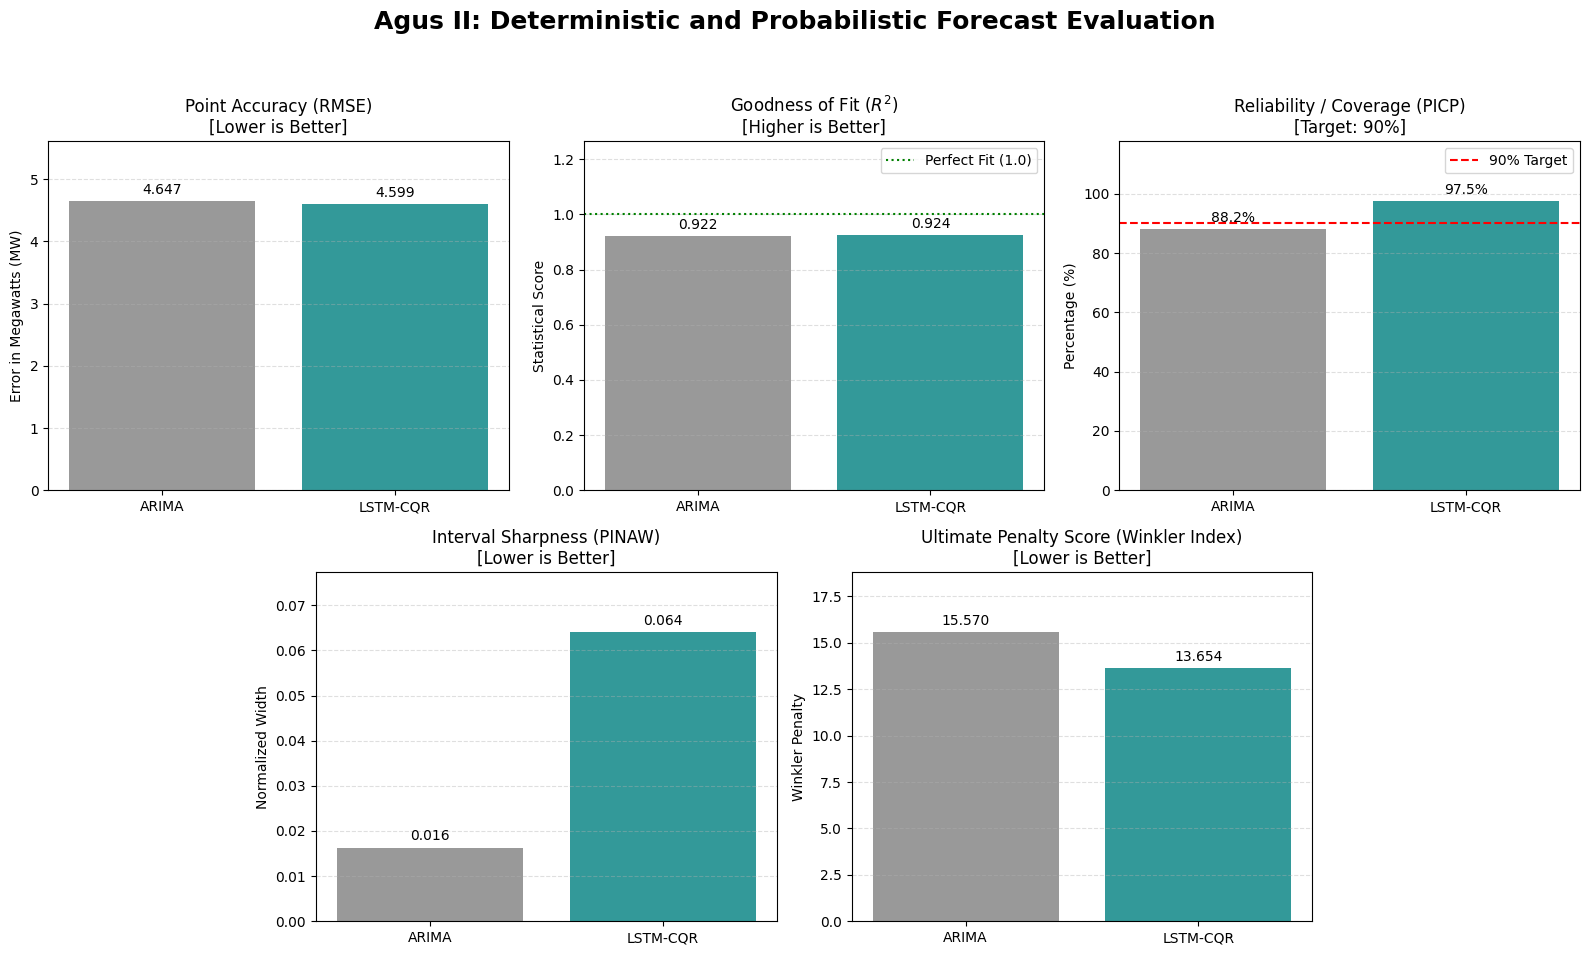

SUCCESS! Comparison table printed and high-res dashboard saved.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error, r2_score

# 1: define function to compute deterministic and probabilistic evaluation metrics 
def calculate_metrics(df_path, alpha=0.10):
    df = pd.read_csv(df_path, index_col='Time', parse_dates=True)
    
    y_true = df['Actual_MW'].values
    y_pred = df['Point_Prediction_MW'].values
    lower_bound = df['Physics_Lower_MW'].values
    upper_bound = df['Physics_Upper_MW'].values

    R = np.max(y_true) - np.min(y_true)

    # Deterministic Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Probabilistic Metrics
    is_covered = (y_true >= lower_bound) & (y_true <= upper_bound)
    picp = np.mean(is_covered) * 100

    widths = upper_bound - lower_bound
    pinaw = np.mean(widths) / R

    # Winkler Index
    penalties = np.zeros_like(y_true)
    miss_low = y_true < lower_bound
    penalties[miss_low] = (2 / alpha) * (lower_bound[miss_low] - y_true[miss_low])
    miss_high = y_true > upper_bound
    penalties[miss_high] = (2 / alpha) * (y_true[miss_high] - upper_bound[miss_high])

    winkler_index = np.mean(widths + penalties)

    return {'RMSE': rmse, 'R2': r2, 'PICP': picp, 'PINAW': pinaw, 'Winkler': winkler_index}

# 2: execute metric calculations for the proposed model and the baseline
cqr_metrics = calculate_metrics('Agus2_Validated_CQR_Results.csv')
arima_metrics = calculate_metrics('Agus2_ARIMA_Baseline_Results.csv')

# 3: output comparative evaluation table
print("\n" + "="*65)
print(f"{'METRIC':<20} | {'ARIMA BASELINE':<20} | {'LSTM-CQR (PROPOSED)':<20}")
print("-" * 65)
print(f"{'RMSE (MW)':<20} | {arima_metrics['RMSE']:<20.4f} | {cqr_metrics['RMSE']:<20.4f}")
print(f"{'R-Squared':<20} | {arima_metrics['R2']:<20.4f} | {cqr_metrics['R2']:<20.4f}")
print(f"{'PICP (%) Target: 90%':<20} | {arima_metrics['PICP']:<20.2f} | {cqr_metrics['PICP']:<20.2f}")
print(f"{'PINAW (Lower=Better)':<20} | {arima_metrics['PINAW']:<20.4f} | {cqr_metrics['PINAW']:<20.4f}")
print(f"{'Winkler (Lower=Better)':<20} | {arima_metrics['Winkler']:<20.4f} | {cqr_metrics['Winkler']:<20.4f}")
print("="*65)

# 4: generate and export the 5-plot comparative visual dashboard
models = ['ARIMA', 'LSTM-CQR']
colors = ['gray', 'teal']

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Agus II: Deterministic and Probabilistic Forecast Evaluation', fontsize=18, fontweight='bold')

# GridSpec to center the 5 plots (3 on top row, 2 centered on bottom row)
gs = gridspec.GridSpec(2, 6, figure=fig)

ax1 = fig.add_subplot(gs[0, 0:2]) # Top Left
ax2 = fig.add_subplot(gs[0, 2:4]) # Top Middle
ax3 = fig.add_subplot(gs[0, 4:6]) # Top Right
ax4 = fig.add_subplot(gs[1, 1:3]) # Bottom Left (Centered)
ax5 = fig.add_subplot(gs[1, 3:5]) # Bottom Right (Centered)

axes = [ax1, ax2, ax3, ax4, ax5]

# Plot 1: RMSE
bars1 = ax1.bar(models, [arima_metrics['RMSE'], cqr_metrics['RMSE']], color=colors, alpha=0.8)
ax1.set_title('Point Accuracy (RMSE)\n[Lower is Better]')
ax1.set_ylabel('Error in Megawatts (MW)')
ax1.bar_label(bars1, fmt='%.3f', padding=3)

# Plot 2: R-Squared (R2)
bars2 = ax2.bar(models, [arima_metrics['R2'], cqr_metrics['R2']], color=colors, alpha=0.8)
ax2.axhline(y=1.0, color='green', linestyle=':', label='Perfect Fit (1.0)')
ax2.set_title('Goodness of Fit ($R^2$)\n[Higher is Better]')
ax2.set_ylabel('Statistical Score')
ax2.set_ylim(0, 1.1) # R2 maxes out at 1.0, giving it a bit of ceiling room
ax2.legend()
ax2.bar_label(bars2, fmt='%.3f', padding=3)

# Plot 3: PICP
bars3 = ax3.bar(models, [arima_metrics['PICP'], cqr_metrics['PICP']], color=colors, alpha=0.8)
ax3.axhline(y=90.0, color='red', linestyle='--', label='90% Target')
ax3.set_title('Reliability / Coverage (PICP)\n[Target: 90%]')
ax3.set_ylabel('Percentage (%)')
ax3.legend()
ax3.bar_label(bars3, fmt='%.1f%%', padding=3)

# Plot 4: PINAW
bars4 = ax4.bar(models, [arima_metrics['PINAW'], cqr_metrics['PINAW']], color=colors, alpha=0.8)
ax4.set_title('Interval Sharpness (PINAW)\n[Lower is Better]')
ax4.set_ylabel('Normalized Width')
ax4.bar_label(bars4, fmt='%.3f', padding=3)

# Plot 5: Winkler Index
bars5 = ax5.bar(models, [arima_metrics['Winkler'], cqr_metrics['Winkler']], color=colors, alpha=0.8)
ax5.set_title('Ultimate Penalty Score (Winkler Index)\n[Lower is Better]')
ax5.set_ylabel('Winkler Penalty')
ax5.bar_label(bars5, fmt='%.3f', padding=3)

# Universal formatting
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    # Give the y-axis a little extra headroom so the bar labels don't get cut off
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, y_max * 1.15) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Agus2_Final_Model_Comparison_5Metrics.png', dpi=500, bbox_inches='tight')
plt.show() 

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

print("Starting Phase 4B: Full Model Comparison (Agus 2)...")

def calculate_metrics(df_path, alpha=0.10):
    """Loads a results CSV and calculates the core thesis metrics."""
    df = pd.read_csv(df_path, index_col='Time', parse_dates=True)
    
    y_true = df['Actual_MW'].values
    y_pred = df['Point_Prediction_MW'].values
    lower_bound = df['Physics_Lower_MW'].values
    upper_bound = df['Physics_Upper_MW'].values

    # Calculate the range of actual data for normalization
    R = np.max(y_true) - np.min(y_true)

    # Deterministic Metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = (rmse / R) * 100  # Normalized RMSE (Statistical %)
    r2 = r2_score(y_true, y_pred)

    # Probabilistic Metrics
    is_covered = (y_true >= lower_bound) & (y_true <= upper_bound)
    picp = np.mean(is_covered) * 100

    widths = upper_bound - lower_bound
    pinaw = np.mean(widths) / R

    # Winkler Index
    penalties = np.zeros_like(y_true)
    miss_low = y_true < lower_bound
    penalties[miss_low] = (2 / alpha) * (lower_bound[miss_low] - y_true[miss_low])
    miss_high = y_true > upper_bound
    penalties[miss_high] = (2 / alpha) * (y_true[miss_high] - upper_bound[miss_high])

    winkler_index = np.mean(widths + penalties)

    return {
        'RMSE': rmse, 
        'NRMSE': nrmse, 
        'R2': r2, 
        'PICP': picp, 
        'PINAW': pinaw, 
        'Winkler': winkler_index
    }

# ==========================================
# 1. CALCULATE ALL METRICS
# ==========================================
# Ensure these filenames exactly match your directory!
cqr_metrics = calculate_metrics('Agus2_Validated_CQR_Results.csv')
arima_metrics = calculate_metrics('Agus2_ARIMA_Baseline_Results.csv')

# ==========================================
# 2. PRINT THE THESIS COMPARISON TABLE
# ==========================================
print("\n" + "="*70)
print(f"{'METRIC':<25} | {'ARIMA BASELINE':<20} | {'LSTM-CQR (PROPOSED)':<20}")
print("-" * 70)
print(f"{'RMSE (MW)':<25} | {arima_metrics['RMSE']:<20.4f} | {cqr_metrics['RMSE']:<20.4f}")
print(f"{'NRMSE (%)':<25} | {arima_metrics['NRMSE']:<20.4f} | {cqr_metrics['NRMSE']:<20.4f}")
print(f"{'R-Squared':<25} | {arima_metrics['R2']:<20.4f} | {cqr_metrics['R2']:<20.4f}")
print(f"{'PICP (%) Target: 90%':<25} | {arima_metrics['PICP']:<20.2f} | {cqr_metrics['PICP']:<20.2f}")
print(f"{'PINAW (Lower=Better)':<25} | {arima_metrics['PINAW']:<20.4f} | {cqr_metrics['PINAW']:<20.4f}")
print(f"{'Winkler (Lower=Better)':<25} | {arima_metrics['Winkler']:<20.4f} | {cqr_metrics['Winkler']:<20.4f}")
print("="*70)

# ==========================================
# 3. GENERATE INDIVIDUAL HIGH-RES PLOTS
# ==========================================
print("\nGenerating individual high-resolution plots...")

models = ['ARIMA', 'LSTM-CQR']
colors = ['#808080', '#008B8B'] # Professional gray and IEEE-friendly blue

def save_individual_plot(metric_key, title, ylabel, filename, is_pct=False, hline=None):
    """Helper function to format and save a single metric plot."""
    fig, ax = plt.subplots(figsize=(6, 5)) # Perfect size for a single column IEEE figure
    
    vals = [arima_metrics[metric_key], cqr_metrics[metric_key]]
    bars = ax.bar(models, vals, color=colors, alpha=0.85, width=0.6)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
    
    # Add a target line if specified (like for PICP or R2)
    if hline:
        ax.axhline(y=hline['val'], color=hline['color'], linestyle=hline['style'], linewidth=2, label=hline['label'])
        ax.legend(loc='lower right' if metric_key == 'R2' else 'best')

    # Add data labels on top of bars
    fmt = '%.2f%%' if is_pct else '%.3f'
    ax.bar_label(bars, fmt=fmt, padding=4, fontsize=10, fontweight='bold')

    # Styling
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Scale Y-axis to prevent label cutoff
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, y_max * 1.15)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=500, bbox_inches='tight')
    plt.close() # Close figure to free memory
    print(f"Saved: {filename}")

# Generate all 6 separate graphs
save_individual_plot('RMSE', 'Point Accuracy (RMSE)\n[Lower is Better]', 'Error in Megawatts (MW)', 'Agus2_Metric_1_RMSE.png')

save_individual_plot('NRMSE', 'Normalized Point Accuracy (NRMSE)\n[Lower is Better]', 'Percentage Error (%)', 'Agus2_Metric_2_NRMSE.png', is_pct=True)

save_individual_plot('R2', 'Goodness of Fit (R-Squared)\n[Higher is Better]', 'Statistical Score', 'Agus2_Metric_3_R2.png', 
                     hline={'val': 1.0, 'color': 'green', 'style': ':', 'label': 'Perfect Fit (1.0)'})

save_individual_plot('PICP', 'Reliability / Coverage (PICP)\n[Target: 90%]', 'Percentage (%)', 'Agus2_Metric_4_PICP.png', is_pct=True, 
                     hline={'val': 90.0, 'color': 'red', 'style': '--', 'label': '90% Target Coverage'})

save_individual_plot('PINAW', 'Interval Sharpness (PINAW)\n[Lower is Better]', 'Normalized Width', 'Agus2_Metric_5_PINAW.png')

save_individual_plot('Winkler', 'Ultimate Penalty Score (Winkler Index)\n[Lower is Better]', 'Winkler Penalty', 'Agus2_Metric_6_Winkler.png')

print("\nSUCCESS! All individual metrics saved as 500 DPI images ready for LaTeX insertion.")

Starting Phase 4B: Full Model Comparison (Agus 2)...

METRIC                    | ARIMA BASELINE       | LSTM-CQR (PROPOSED) 
----------------------------------------------------------------------
RMSE (MW)                 | 4.6469               | 4.5990              
NRMSE (%)                 | 3.9370               | 3.8964              
R-Squared                 | 0.9218               | 0.9241              
PICP (%) Target: 90%      | 88.17                | 97.46               
PINAW (Lower=Better)      | 0.0163               | 0.0640              
Winkler (Lower=Better)    | 15.5701              | 13.6540             

Generating individual high-resolution plots...
Saved: Agus2_Metric_1_RMSE.png
Saved: Agus2_Metric_2_NRMSE.png
Saved: Agus2_Metric_3_R2.png
Saved: Agus2_Metric_4_PICP.png
Saved: Agus2_Metric_5_PINAW.png
Saved: Agus2_Metric_6_Winkler.png

SUCCESS! All individual metrics saved as 500 DPI images ready for LaTeX insertion.


Generating Comparative Daily Percent Error Bar Chart...


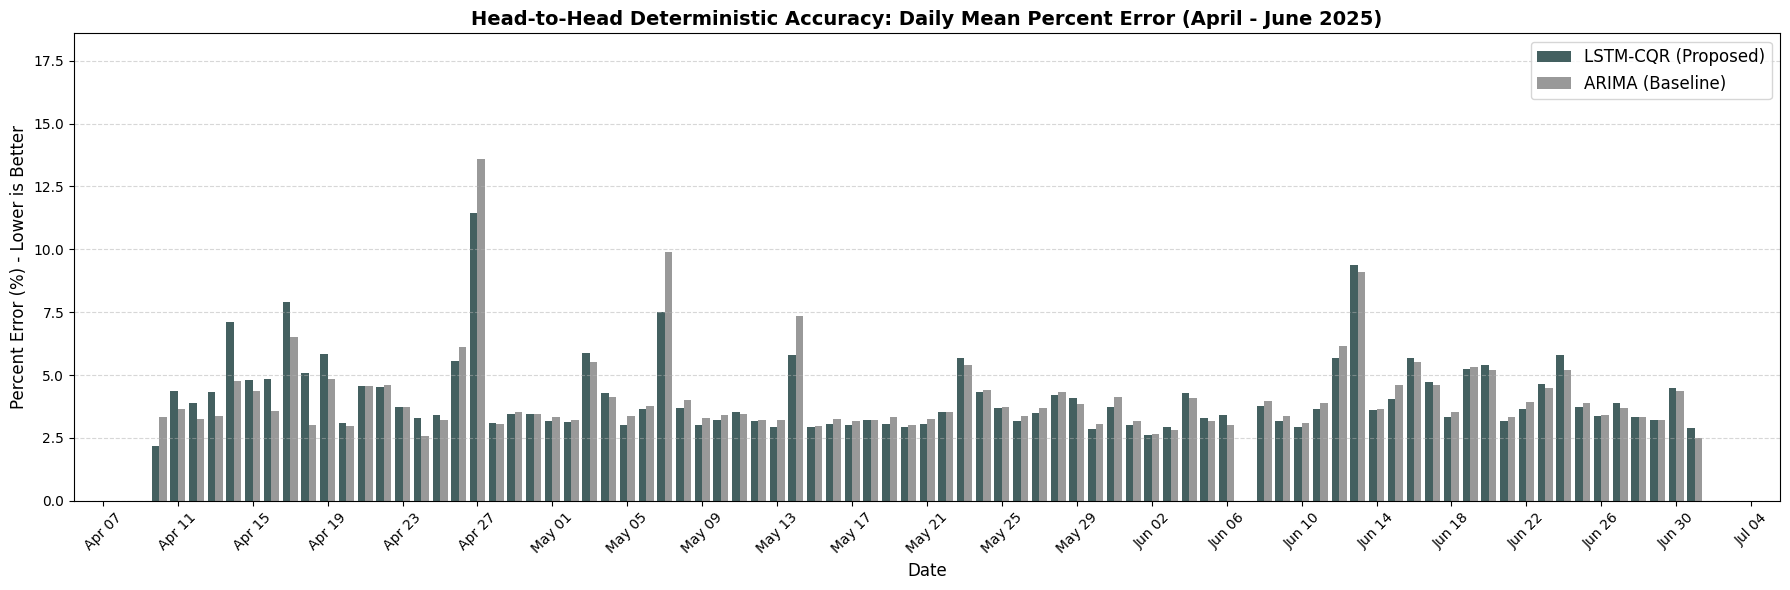

SUCCESS! Comparative Percent Error chart saved.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Comparative Daily Percent Error Bar Chart...")

# 1. Load the Results (with dayfirst=True)
df_lstm = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)
df_arima = pd.read_csv('Agus1_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True, dayfirst=True) 

# 1A. THE FIX: Explicitly force the index to be datetime objects
df_lstm.index = pd.to_datetime(df_lstm.index, format='mixed', dayfirst=True)
df_arima.index = pd.to_datetime(df_arima.index, format='mixed', dayfirst=True)

# 1B. Exclude June 7, 2025 to prevent MAPE mathematical singularity
df_lstm = df_lstm[~((df_lstm.index.month == 6) & (df_lstm.index.day == 7))]
df_arima = df_arima[~((df_arima.index.month == 6) & (df_arima.index.day == 7))]

# 2. Function to Calculate Percent Error
def calculate_percent_error(df):
    actuals_safe = df['Actual_MW'].replace(0, np.nan)
    return (abs(df['Actual_MW'] - df['Point_Prediction_MW']) / actuals_safe) * 100

# Calculate for both and resample to daily mean
daily_lstm = calculate_percent_error(df_lstm).resample('D').mean().dropna()
daily_arima = calculate_percent_error(df_arima).resample('D').mean().dropna()

# Align the data perfectly by index
df_compare = pd.DataFrame({'LSTM': daily_lstm, 'ARIMA': daily_arima}).dropna()

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(18, 6))

# Convert dates to numerical format for precise side-by-side shifting
x = mdates.date2num(df_compare.index)
bar_width = 0.4 

# Plot LSTM (Green) and ARIMA (Gray/Black)
plt.bar(x - bar_width/2, df_compare['LSTM'], width=bar_width, color='#2F4F4F', label='LSTM-CQR (Proposed)', alpha=0.9)
plt.bar(x + bar_width/2, df_compare['ARIMA'], width=bar_width, color='#808080', label='ARIMA (Baseline)', alpha=0.8)

# 4. Professional Academic Formatting
plt.title('Head-to-Head Deterministic Accuracy: Daily Mean Percent Error (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percent Error (%) - Lower is Better', fontsize=12)

# Format x-axis to show the dates
plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df_compare.max().max() + 5) # Scale slightly above the highest bar

plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Comparative_Percent_Error.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Comparative Percent Error chart saved.")

Generating Comparative Daily Percent Error Bar Chart...


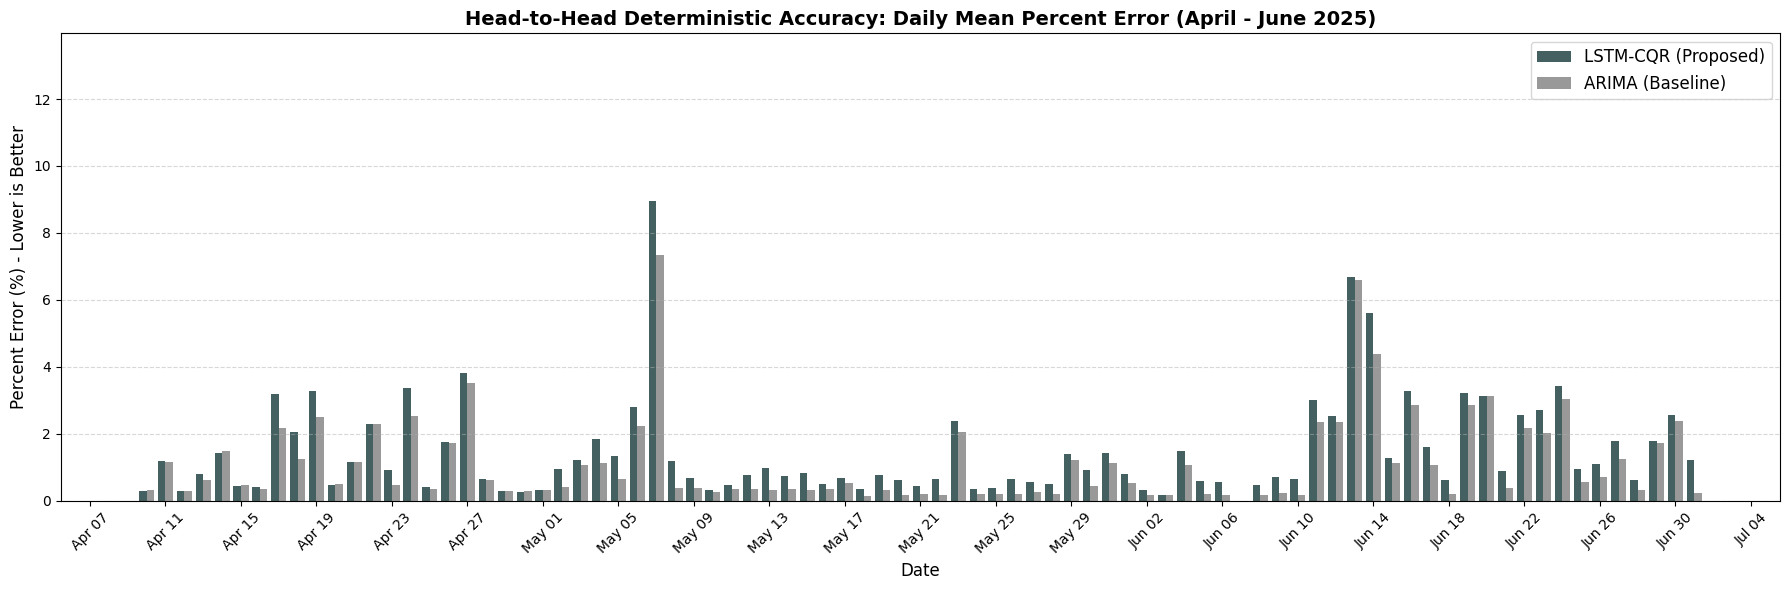

SUCCESS! Comparative Percent Error chart saved.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Comparative Daily Percent Error Bar Chart...")

# 1. Load the Results (with dayfirst=True)
df_lstm = pd.read_csv('Agus2_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)
df_arima = pd.read_csv('Agus2_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True, dayfirst=True) 

# 1A. THE FIX: Explicitly force the index to be datetime objects
df_lstm.index = pd.to_datetime(df_lstm.index, format='mixed', dayfirst=True)
df_arima.index = pd.to_datetime(df_arima.index, format='mixed', dayfirst=True)

# 1B. Exclude June 7, 2025 to prevent MAPE mathematical singularity
df_lstm = df_lstm[~((df_lstm.index.month == 6) & (df_lstm.index.day == 7))]
df_arima = df_arima[~((df_arima.index.month == 6) & (df_arima.index.day == 7))]

# 2. Function to Calculate Percent Error
def calculate_percent_error(df):
    actuals_safe = df['Actual_MW'].replace(0, np.nan)
    return (abs(df['Actual_MW'] - df['Point_Prediction_MW']) / actuals_safe) * 100

# Calculate for both and resample to daily mean
daily_lstm = calculate_percent_error(df_lstm).resample('D').mean().dropna()
daily_arima = calculate_percent_error(df_arima).resample('D').mean().dropna()

# Align the data perfectly by index
df_compare = pd.DataFrame({'LSTM': daily_lstm, 'ARIMA': daily_arima}).dropna()

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(18, 6))

# Convert dates to numerical format for precise side-by-side shifting
x = mdates.date2num(df_compare.index)
bar_width = 0.4 

# Plot LSTM (Green) and ARIMA (Gray/Black)
plt.bar(x - bar_width/2, df_compare['LSTM'], width=bar_width, color='#2F4F4F', label='LSTM-CQR (Proposed)', alpha=0.9)
plt.bar(x + bar_width/2, df_compare['ARIMA'], width=bar_width, color='#808080', label='ARIMA (Baseline)', alpha=0.8)

# 4. Professional Academic Formatting
plt.title('Head-to-Head Deterministic Accuracy: Daily Mean Percent Error (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percent Error (%) - Lower is Better', fontsize=12)

# Format x-axis to show the dates
plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df_compare.max().max() + 5) # Scale slightly above the highest bar

plt.tight_layout()

# Save and Show
plt.savefig('Agus2_Comparative_Percent_Error.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Comparative Percent Error chart saved.")

Generating Comparative Daily RMSE Bar Chart...


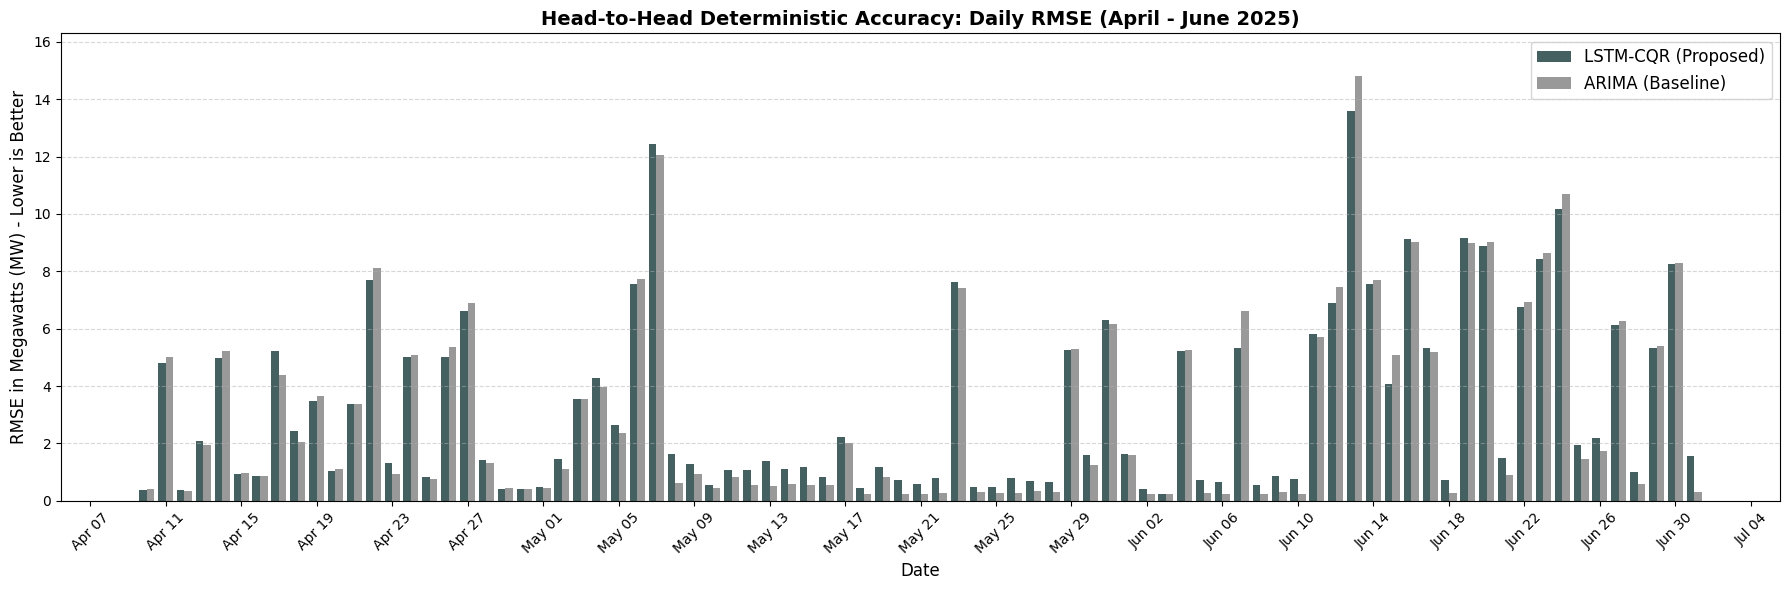

SUCCESS! Comparative RMSE chart saved.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Comparative Daily RMSE Bar Chart...")

# 1. Load the Results (with dayfirst=True)
df_lstm = pd.read_csv('Agus2_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)
df_arima = pd.read_csv('Agus2_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True, dayfirst=True) 

# 1A. Explicitly force the index to be datetime objects
df_lstm.index = pd.to_datetime(df_lstm.index, format='mixed', dayfirst=True)
df_arima.index = pd.to_datetime(df_arima.index, format='mixed', dayfirst=True)

# 2. Function to Calculate Daily RMSE
def calculate_daily_rmse(df):
    # Calculate squared error for every 15-minute interval
    squared_errors = (df['Actual_MW'] - df['Point_Prediction_MW']) ** 2
    
    # Resample to daily average (MSE), then take the square root to get daily RMSE
    daily_mse = squared_errors.resample('D').mean()
    daily_rmse = np.sqrt(daily_mse)
    
    return daily_rmse.dropna()

# Calculate for both models
daily_lstm = calculate_daily_rmse(df_lstm)
daily_arima = calculate_daily_rmse(df_arima)

# Align the data perfectly by index
df_compare = pd.DataFrame({'LSTM': daily_lstm, 'ARIMA': daily_arima}).dropna()

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(18, 6))

# Convert dates to numerical format for precise side-by-side shifting
x = mdates.date2num(df_compare.index)
bar_width = 0.4 

# Plot LSTM (Green) and ARIMA (Gray/Black)
plt.bar(x - bar_width/2, df_compare['LSTM'], width=bar_width, color='#2F4F4F', label='LSTM-CQR (Proposed)', alpha=0.9)
plt.bar(x + bar_width/2, df_compare['ARIMA'], width=bar_width, color='#808080', label='ARIMA (Baseline)', alpha=0.8)

# 4. Professional Academic Formatting
plt.title('Head-to-Head Deterministic Accuracy: Daily RMSE (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('RMSE in Megawatts (MW) - Lower is Better', fontsize=12)

# Format x-axis to show the dates
plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Scale slightly above the highest bar for neatness
plt.ylim(0, df_compare.max().max() * 1.1) 

plt.tight_layout()

# Save and Show
plt.savefig('Agus2_Comparative_RMSE.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Comparative RMSE chart saved.")

Generating Comparative Daily RMSE Bar Chart...


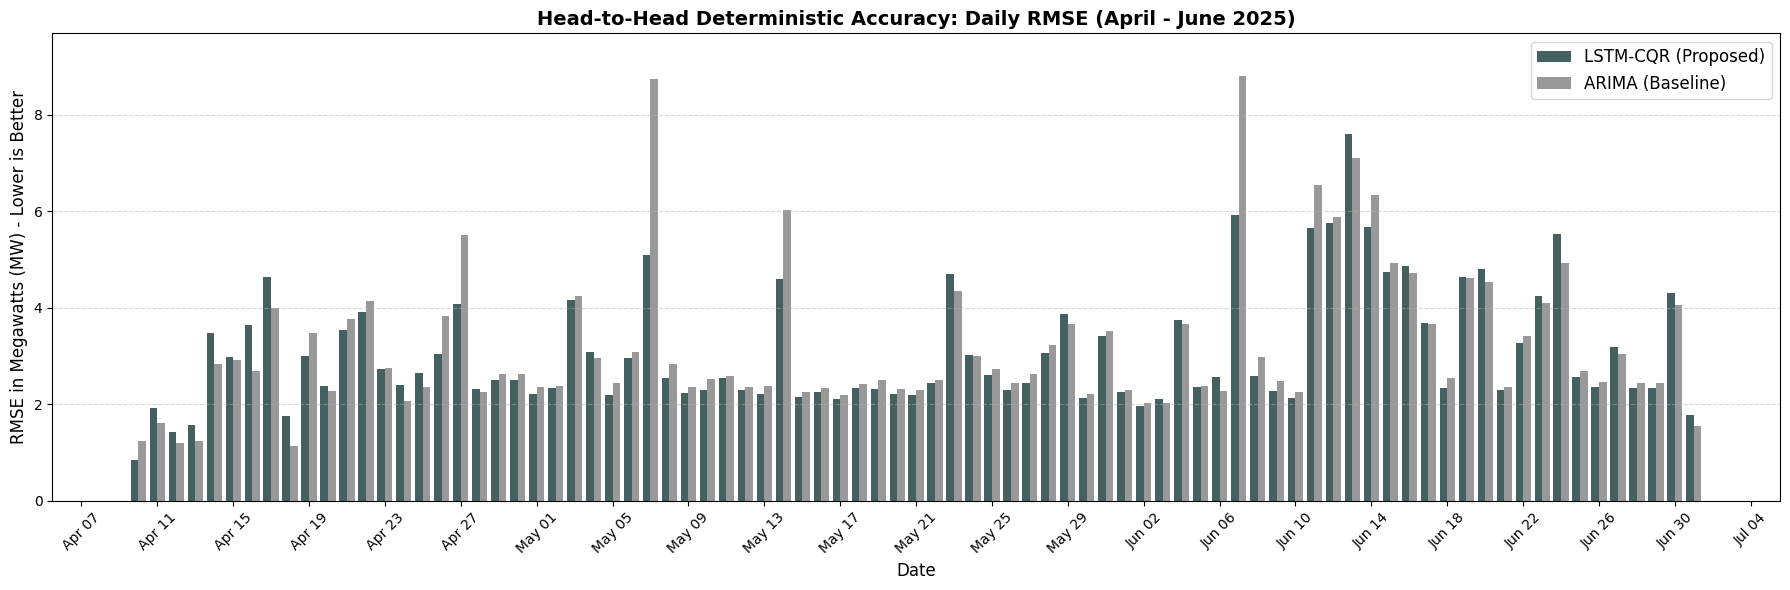

SUCCESS! Comparative RMSE chart saved.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Comparative Daily RMSE Bar Chart...")

# 1. Load the Results (with dayfirst=True)
df_lstm = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)
df_arima = pd.read_csv('Agus1_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True, dayfirst=True) 

# 1A. Explicitly force the index to be datetime objects
df_lstm.index = pd.to_datetime(df_lstm.index, format='mixed', dayfirst=True)
df_arima.index = pd.to_datetime(df_arima.index, format='mixed', dayfirst=True)

# 2. Function to Calculate Daily RMSE
def calculate_daily_rmse(df):
    # Calculate squared error for every 15-minute interval
    squared_errors = (df['Actual_MW'] - df['Point_Prediction_MW']) ** 2
    
    # Resample to daily average (MSE), then take the square root to get daily RMSE
    daily_mse = squared_errors.resample('D').mean()
    daily_rmse = np.sqrt(daily_mse)
    
    return daily_rmse.dropna()

# Calculate for both models
daily_lstm = calculate_daily_rmse(df_lstm)
daily_arima = calculate_daily_rmse(df_arima)

# Align the data perfectly by index
df_compare = pd.DataFrame({'LSTM': daily_lstm, 'ARIMA': daily_arima}).dropna()

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(18, 6))

# Convert dates to numerical format for precise side-by-side shifting
x = mdates.date2num(df_compare.index)
bar_width = 0.4 

# Plot LSTM (Green) and ARIMA (Gray/Black)
plt.bar(x - bar_width/2, df_compare['LSTM'], width=bar_width, color='#2F4F4F', label='LSTM-CQR (Proposed)', alpha=0.9)
plt.bar(x + bar_width/2, df_compare['ARIMA'], width=bar_width, color='#808080', label='ARIMA (Baseline)', alpha=0.8)

# 4. Professional Academic Formatting
plt.title('Head-to-Head Deterministic Accuracy: Daily RMSE (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('RMSE in Megawatts (MW) - Lower is Better', fontsize=12)

# Format x-axis to show the dates
plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Scale slightly above the highest bar for neatness
plt.ylim(0, df_compare.max().max() * 1.1) 

plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Comparative_RMSE.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Comparative RMSE chart saved.")

Generating Comparative Daily Winkler Penalty Tracker...


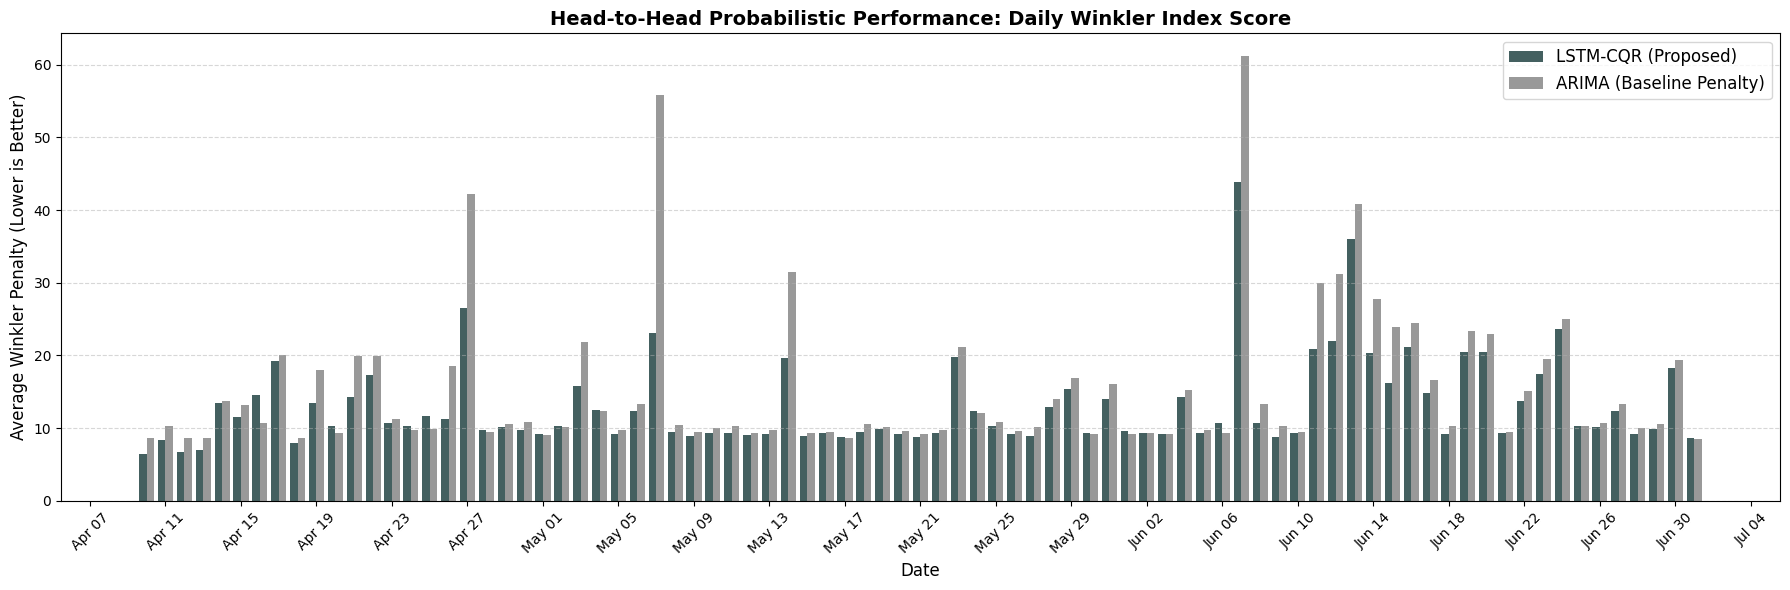

SUCCESS! Comparative Winkler plot saved.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Comparative Daily Winkler Penalty Tracker...")

# 1. Load the Results (WITH DATETIME FIXES AND CORRECTED FILENAMES)
df_lstm = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)
df_arima = pd.read_csv('Agus1_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True, dayfirst=True) 

# Explicitly force the index to be datetime objects to prevent resampling errors
df_lstm.index = pd.to_datetime(df_lstm.index, format='mixed', dayfirst=True)
df_arima.index = pd.to_datetime(df_arima.index, format='mixed', dayfirst=True)

alpha = 0.10  # 90% Confidence

# 2. Function to Calculate Winkler Score
def calculate_winkler(df):
    width = df['Physics_Upper_MW'] - df['Physics_Lower_MW']
    score = width.copy()
    
    # Penalties for dropping below lower bound
    low_mask = df['Actual_MW'] < df['Physics_Lower_MW']
    score.loc[low_mask] += (2 / alpha) * (df.loc[low_mask, 'Physics_Lower_MW'] - df.loc[low_mask, 'Actual_MW'])
    
    # Penalties for spiking above upper bound
    high_mask = df['Actual_MW'] > df['Physics_Upper_MW']
    score.loc[high_mask] += (2 / alpha) * (df.loc[high_mask, 'Actual_MW'] - df.loc[high_mask, 'Physics_Upper_MW'])
    
    return score

# Calculate for both and resample to daily mean
daily_winkler_lstm = calculate_winkler(df_lstm).resample('D').mean().dropna()
daily_winkler_arima = calculate_winkler(df_arima).resample('D').mean().dropna()

# Align the data perfectly by index
df_compare_w = pd.DataFrame({'LSTM': daily_winkler_lstm, 'ARIMA': daily_winkler_arima}).dropna()

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(18, 6))

x = mdates.date2num(df_compare_w.index)
bar_width = 0.4 

# Plot LSTM (Green) and ARIMA (Deep Red to signify its heavy penalties)
plt.bar(x - bar_width/2, df_compare_w['LSTM'], width=bar_width, color='#2F4F4F', label='LSTM-CQR (Proposed)', alpha=0.9)
plt.bar(x + bar_width/2, df_compare_w['ARIMA'], width=bar_width, color='#808080', label='ARIMA (Baseline Penalty)', alpha=0.8)

# 4. Professional Academic Formatting
plt.title('Head-to-Head Probabilistic Performance: Daily Winkler Index Score', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Winkler Penalty (Lower is Better)', fontsize=12)

plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Comparative_Winkler_Score.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Comparative Winkler plot saved.")

Generating Comparative Daily Winkler Penalty Tracker...


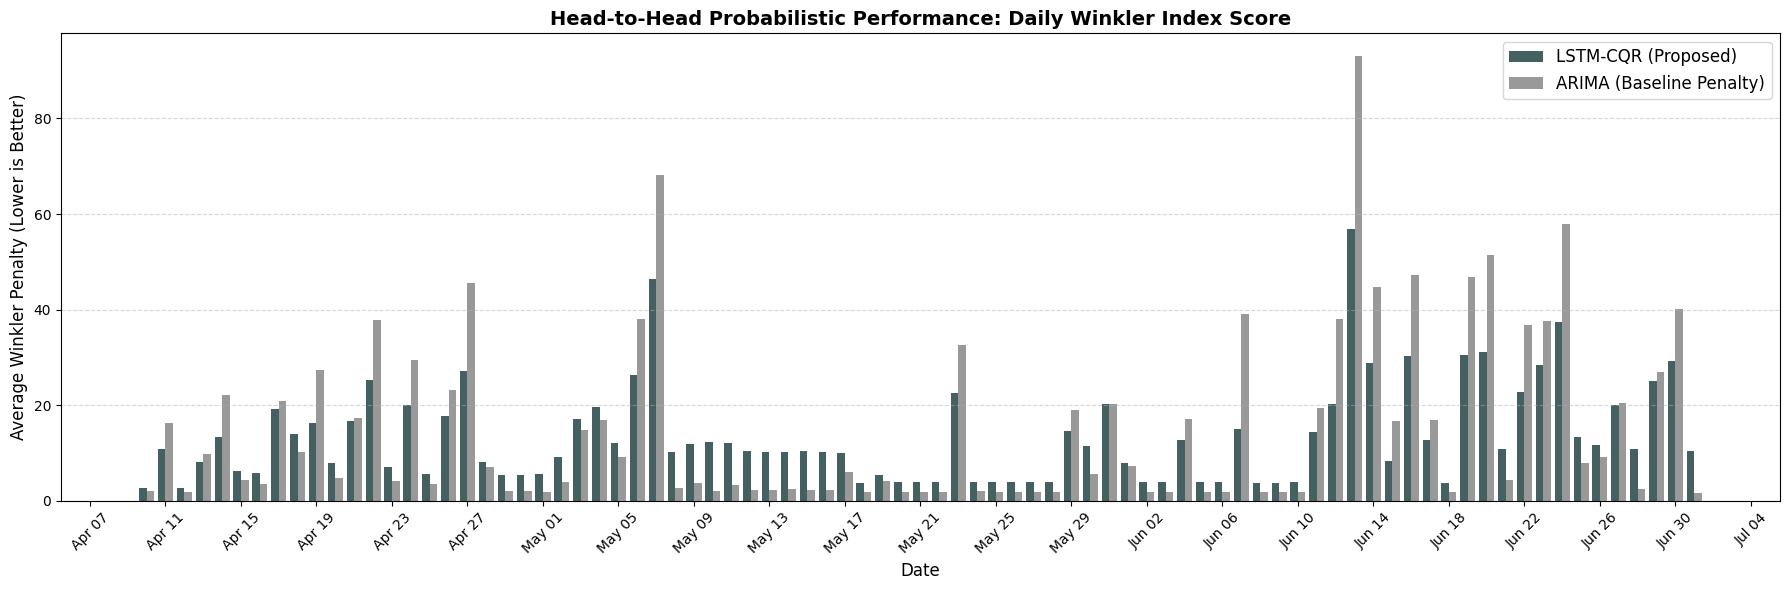

SUCCESS! Comparative Winkler plot saved.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Comparative Daily Winkler Penalty Tracker...")

# 1. Load the Results (WITH DATETIME FIXES AND CORRECTED FILENAMES)
df_lstm = pd.read_csv('Agus2_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)
df_arima = pd.read_csv('Agus2_ARIMA_Baseline_Results.csv', index_col='Time', parse_dates=True, dayfirst=True) 

# Explicitly force the index to be datetime objects to prevent resampling errors
df_lstm.index = pd.to_datetime(df_lstm.index, format='mixed', dayfirst=True)
df_arima.index = pd.to_datetime(df_arima.index, format='mixed', dayfirst=True)

alpha = 0.10  # 90% Confidence

# 2. Function to Calculate Winkler Score
def calculate_winkler(df):
    width = df['Physics_Upper_MW'] - df['Physics_Lower_MW']
    score = width.copy()
    
    # Penalties for dropping below lower bound
    low_mask = df['Actual_MW'] < df['Physics_Lower_MW']
    score.loc[low_mask] += (2 / alpha) * (df.loc[low_mask, 'Physics_Lower_MW'] - df.loc[low_mask, 'Actual_MW'])
    
    # Penalties for spiking above upper bound
    high_mask = df['Actual_MW'] > df['Physics_Upper_MW']
    score.loc[high_mask] += (2 / alpha) * (df.loc[high_mask, 'Actual_MW'] - df.loc[high_mask, 'Physics_Upper_MW'])
    
    return score

# Calculate for both and resample to daily mean
daily_winkler_lstm = calculate_winkler(df_lstm).resample('D').mean().dropna()
daily_winkler_arima = calculate_winkler(df_arima).resample('D').mean().dropna()

# Align the data perfectly by index
df_compare_w = pd.DataFrame({'LSTM': daily_winkler_lstm, 'ARIMA': daily_winkler_arima}).dropna()

# 3. Create the Side-by-Side Bar Chart
plt.figure(figsize=(18, 6))

x = mdates.date2num(df_compare_w.index)
bar_width = 0.4 

# Plot LSTM (Green) and ARIMA (Deep Red to signify its heavy penalties)
plt.bar(x - bar_width/2, df_compare_w['LSTM'], width=bar_width, color='#2F4F4F', label='LSTM-CQR (Proposed)', alpha=0.9)
plt.bar(x + bar_width/2, df_compare_w['ARIMA'], width=bar_width, color='#808080', label='ARIMA (Baseline Penalty)', alpha=0.8)

# 4. Professional Academic Formatting
plt.title('Head-to-Head Probabilistic Performance: Daily Winkler Index Score', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Winkler Penalty (Lower is Better)', fontsize=12)

plt.gca().xaxis_date()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.legend(loc='upper right', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save and Show
plt.savefig('Agus2_Comparative_Winkler_Score.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Comparative Winkler plot saved.")